In [1]:
libraries = c("dplyr", "tidyverse", "magrittr", "ggplot2", "zoo", "rstan")
for(x in libraries) {library(x,character.only = TRUE, warn.conflicts = FALSE, quietly = TRUE)}
theme_set(theme_bw())

options(scipen = 999)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.5
✔ ggplot2   4.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.2.0     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

rstan version 2.32.7 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain

In [2]:
source("seroprev_constant_FoI_comparison.r")

In [3]:
## settings
target_foi <- rev(target_foi)
foi_profile_list <- lapply(target_foi * .01, rep, times = group_num)
sample <- 1000

# Age-constant FoI catalytic model

In [4]:
rstan_options(auto_write = TRUE)
options(mc.cores = parallel::detectCores())
rstan_options(threads_per_chain = 1)

In [5]:
## naive discrete catalytic model with age-group-based seroprevalence data
naive_model_single_group = "
data {
    int<lower=1> N;
    array[N] int<lower=0> n_positive;  
    array[N] int<lower=0> n_sample;  
    vector[N] age_lower;
    vector[N] age_upper;
    real<lower=0> foi_prior_median;
}

parameters {
    real<lower=1e-6> foi;
}

transformed parameters {
    vector[N] prev_hat;
    real eps = 1e-12;

    for (i in 1:N) {
        real L = age_lower[i];
        real U = age_upper[i];
        real w = U - L;

        real avg_prev = 1 - (exp(-foi * L) - exp(-foi * U)) / (w * foi);
        prev_hat[i] = fmin(fmax(avg_prev, eps), 1 - eps);
    }
}

model {
    foi ~ lognormal(log(foi_prior_median), 0.7);
    n_positive ~ binomial(n_sample, prev_hat);
}"


In [6]:
## adjusted discrete catalytic model with age-group-based seroprevalence data
adjust_model_single_group = "
data {
    int<lower=1> N;
    array[N] int<lower=0> n_positive;
    array[N] int<lower=0> n_sample;
    vector[N] age_lower;
    vector[N] age_upper;
    vector<lower=0, upper=1>[N] ifr_profile;
    real<lower=0> foi_prior_median;
}

parameters {
    real<lower=1e-6> foi;
}

transformed parameters {
    vector[N] prev_hat;
    real eps;
    
    vector[N] w;
    real surv_start;

    eps = 1e-12;
    for (i in 1:N)
        w[i] = age_upper[i] - age_lower[i];

    surv_start = 0;  // immune survivors prob at age group start

    for (i in 1:N) {
        real A = surv_start;
        real lam = foi;
        real wi = w[i];
        real IFR = ifr_profile[i];
        
        real C = exp(-lam * age_lower[i]);
        real x = lam * wi;
        real uw = exp(-x);
        real one_minus_uw = -expm1(-x);

        real raw_prev;

        if (IFR < 1e-8) {
            real denom = A + C;
            raw_prev = 1 - (C / denom) * one_minus_uw / x;
        } else {
            real denom0 = A + C;
            real denom1 = A + C * (1 - IFR) + C * IFR * uw;

            real log_ratio = -log1p( (denom1 - denom0) / denom0 );
            raw_prev = 1 - (1 / (x * IFR)) * log_ratio;
        }

        prev_hat[i] = fmin(fmax(raw_prev, eps), 1 - eps);
        surv_start += C * one_minus_uw * (1 - IFR);
    }
}

model {
    foi ~ lognormal(log(foi_prior_median), 0.7);
    n_positive ~ binomial(n_sample, prev_hat);
}
"

In [7]:
## compiling
sm_naive  <- stan_model(model_code = naive_model_single_group)
sm_adjust <- stan_model(model_code = adjust_model_single_group)

# sampling
run_catalytic <- function(sm, stan_data, init_val = .01) {
    fit <- sampling(object = sm, data = stan_data,
                    chains = 4, iter = 5000, warmup = 1000, thin = 1,
                    control = list(adapt_delta = .99, max_treedepth = 12),
                    init = function() list(foi = init_val))
  
    smry <- summary(fit, pars = "foi")$summary
    out <- data.frame(est_med = smry[, "50%"], est_lower = smry[, "2.5%"], est_25 = smry[, "25%"],
                      est_75 = smry[, "75%"], est_upper = smry[, "97.5%"])
   
    return(list(fit = fit, summary = out))
}

## containers
plots_naive_list <- replicate(3, vector("list", 3), simplify = FALSE)
plots_adjusted_list <- replicate(3, vector("list", 3), simplify = FALSE)
estimates_naive <- replicate(3, vector("list", 3), simplify = FALSE)
estimates_adjusted <- replicate(3, vector("list", 3), simplify = FALSE)

## estimation
foi_index_for_ifr <- c("Decreasing IFR" = 1, "U-shaped IFR" = 2, "Increasing IFR" = 3)

for (i in 1:length(IFR_class)) {
    this_ifr_class <- trimws(as.character(IFR_class[i]))
    foi_idx <- as.integer(unname(foi_index_for_ifr[this_ifr_class]))

    for (l in 1:length(target_IFR)) {
        ## observed sero data
        ifr_profile <- ifr_profile_scale_list[[i]][[l]]

        observed_df <- plot_data %>% 
        filter(scenario  == IFR_class[i], foi_level == paste0("FoI (", target_foi[foi_idx], "%)"),
               ifr_level == paste0("IFR (", target_IFR[l], "%)"), Group == "Observed") %>%
        mutate(n_sample = sample, n_positive = round(prev * n_sample), 
               age_upper = age_group, age_lower = age_group - 10,
               true_foi = as.numeric(stringr::str_extract(foi_level, "[0-9.]+")) * .01)

        true_foi_scalar <- unique(observed_df$true_foi)
        
        stan_data_base <- list(N = nrow(observed_df), n_positive = observed_df$n_positive, n_sample = observed_df$n_sample,
                               age_lower = observed_df$age_lower, age_upper = observed_df$age_upper, 
                               foi_prior_median = true_foi_scalar)

        ## naive model
        res_naive <- run_catalytic(sm_naive, stan_data_base, init_val = true_foi_scalar)
        estimates_naive[[i]][[l]] <- res_naive$summary %>%
        mutate(group = "Naive", correct = true_foi_scalar,
               coverage_95 = (est_lower <= correct & est_upper >= correct) * 1,
               coverage_50 = (est_25 <= correct & est_75 >= correct) * 1)
        plots_naive_list[[i]][[l]] <- traceplot(res_naive$fit, pars = "foi", inc_warmup = FALSE)

        ## adjusted model
        ifr_profile_use <- ifr_profile[seq_len(stan_data_base$N)]
        stan_data_adj <- c(stan_data_base, list(ifr_profile = ifr_profile_use))
        res_adj <- run_catalytic(sm_adjust, stan_data_adj, init_val = true_foi_scalar)

        estimates_adjusted[[i]][[l]] <- res_adj$summary %>%
            mutate(group = "Adjusted", correct = true_foi_scalar,
                   coverage_95 = (est_lower <= correct & est_upper >= correct) * 1,
                   coverage_50 = (est_25 <= correct & est_75 >= correct) * 1)
        plots_adjusted_list[[i]][[l]] <- traceplot(res_adj$fit, pars = "foi", inc_warmup = FALSE)
    }
}

 4: 
                0.105 seconds (Total)
Chain 3: 


est_med,est_lower,est_25,est_75,est_upper,group,correct,coverage_95,coverage_50
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
0.028559,0.02778806,0.02828378,0.02882322,0.02935111,Naive,0.03,0,0


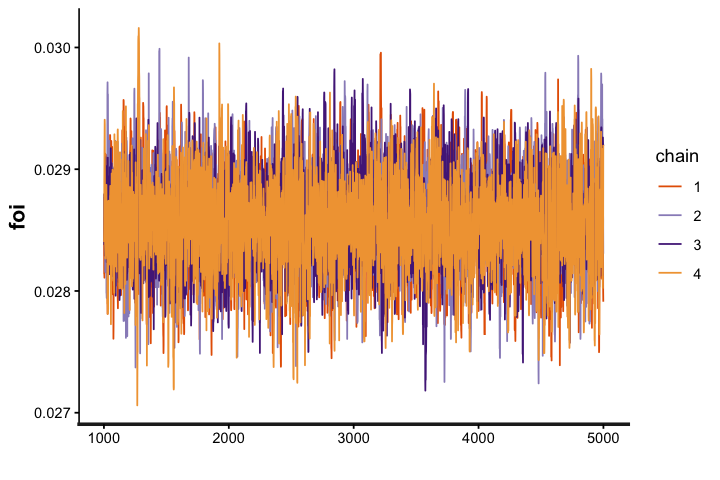

In [8]:
## sanity check for convergence
options(repr.plot.width = 6, repr.plot.height = 4)
plots_naive_list[[1]][[4]]
estimates_naive[[1]][[4]]

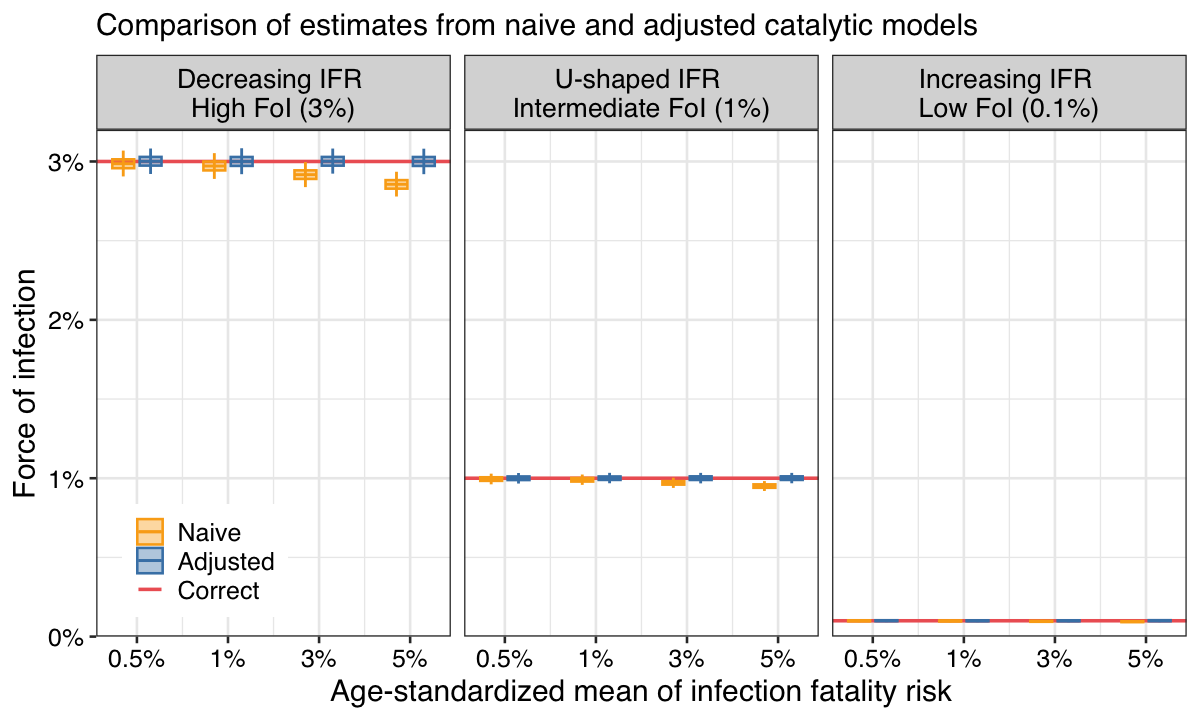

In [20]:
## plotting
n_age_groups <- length(foi_profile_list[[1]])

list_to_df <- function(est_list, IFR_class, target_IFR, group_name, n_age){
    imap_dfr(est_list, function(sublist_i, i) {
        imap_dfr(sublist_i, function(df_l, l) {
            if (is.null(df_l) || nrow(df_l) == 0) return(NULL)
            est <- df_l[1, ]
            tibble(age = 0:(n_age-1), group = group_name, foi = est$est_med,
                   IFR_class = trimws(as.character(IFR_class[i])),
                   IFR_level = paste0("IFR (", target_IFR[l], "%)"), 
                   est_lower = est$est_lower, est_upper = est$est_upper, est_25 = est$est_25, est_75 = est$est_75)})
    })
}

naive_df <- list_to_df(estimates_naive, IFR_class, target_IFR, "Naive", n_age_groups)
adj_df <- list_to_df(estimates_adjusted, IFR_class, target_IFR, "Adjusted", n_age_groups)

correct_df <- imap_dfr(IFR_class, function(cls, i){
    cls <- trimws(as.character(cls))
    foi_idx  <- as.integer(unname(foi_index_for_ifr[cls]))
    foi_true <- foi_profile_list[[foi_idx]][1]
    tibble(IFR_class = cls, foi = foi_true, group = "Correct")})

df_est <- bind_rows(naive_df, adj_df) %>%  group_by(IFR_class, IFR_level, group) %>%
summarise(foi = first(foi), est_lower = first(est_lower), est_upper = first(est_upper),
          est_25 = first(est_25), est_75 = first(est_75), .groups = "drop")

if_levels <- paste0("IFR (", target_IFR, "%)")
if_labels <- paste0(target_IFR, "%")
class_lvls  <- c("Decreasing IFR", "U-shaped IFR", "Increasing IFR")

df_est %<>% mutate(IFR_level = factor(IFR_level, levels = if_levels, labels = if_labels),
                   IFR_class = factor(IFR_class, levels = class_lvls),
                   group = factor(group, levels = c("Correct", "Naive", "Adjusted")))

correct_df %<>% mutate(IFR_class = factor(IFR_class, levels = class_lvls),
                       group = factor(group, levels = c("Correct", "Naive", "Adjusted")))

df_est_box <- df_est %>% 
mutate(x_base = as.numeric(IFR_level),
       x_center = case_when(group == "Naive" ~ x_base - .15, group == "Adjusted" ~ x_base + .15, TRUE ~ x_base),
       IFR_class_label = factor(IFR_class, levels = c("Decreasing IFR", "U-shaped IFR", "Increasing IFR"),
                                labels = c(paste0("Decreasing IFR \nHigh FoI (", target_foi[1], "%)"),
                                           paste0("U-shaped IFR \nIntermediate FoI (", target_foi[2], "%)"),
                                           paste0("Increasing IFR \nLow FoI (", target_foi[3], "%)"))))

merge(df_est_box, correct_df %>% dplyr::select(IFR_class, foi) %>% rename(correct = foi), by = c("IFR_class"), all.x = TRUE) -> df_est_box

options(repr.plot.width = 10, repr.plot.height = 6)

ggplot() +
geom_hline(data = df_est_box, aes(yintercept = correct, color = "Correct"), linewidth = 1 ) +
geom_segment(data = df_est_box, aes(x = x_center, xend = x_center, y = est_lower, yend = est_upper, color = group), linewidth = .8) +
geom_rect(data = df_est_box, aes(xmin = x_center - .12, xmax = x_center + .12, 
                                 ymin = est_25, ymax = est_75, fill = group, color = group), alpha = .4) +
geom_segment(data = df_est_box, aes(x = x_center - .12, xend = x_center + .12, y = foi, yend = foi, color = group), linewidth = .8) +
facet_grid(. ~ IFR_class_label) +
scale_color_manual(values = c("Correct" = "indianred2", "Naive" = "#FAAB18", "Adjusted" = "steelblue"),
                   guide = guide_legend(override.aes = list( fill = c("#FAAB18", "steelblue", NA)))) +
scale_fill_manual(values = c("Correct" = "indianred2", "Naive" = "#FAAB18", "Adjusted" = "steelblue"), guide = "none") +
scale_x_continuous(breaks = 1:length(target_IFR), labels = if_labels,
                   name = "Age-standardized mean of infection fatality risk") +
scale_y_continuous(limits = c(0, .032), expand = c(0, 0), labels = scales::percent_format(accuracy = 1),
                   name = "Force of infection") +
labs(title = "Comparison of estimates from naive and adjusted catalytic models") +
theme_bw(base_size = 16) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 15, family = "sans", color = "black"),
      legend.position = "inside", legend.position.inside = c(.1, .15),
      legend.text = element_text(size = 15, color = "black"), legend.title = element_blank(),
      plot.title = element_text(size = 18, family = "sans", color = "black"),
      strip.text = element_text(size = 16, family = "sans", color = "black"),
      legend.key = element_rect(fill = "transparent"))

ggsave("figures/comparison_single_box.png", width = 10, height = 6, dpi = 300, bg = "white")

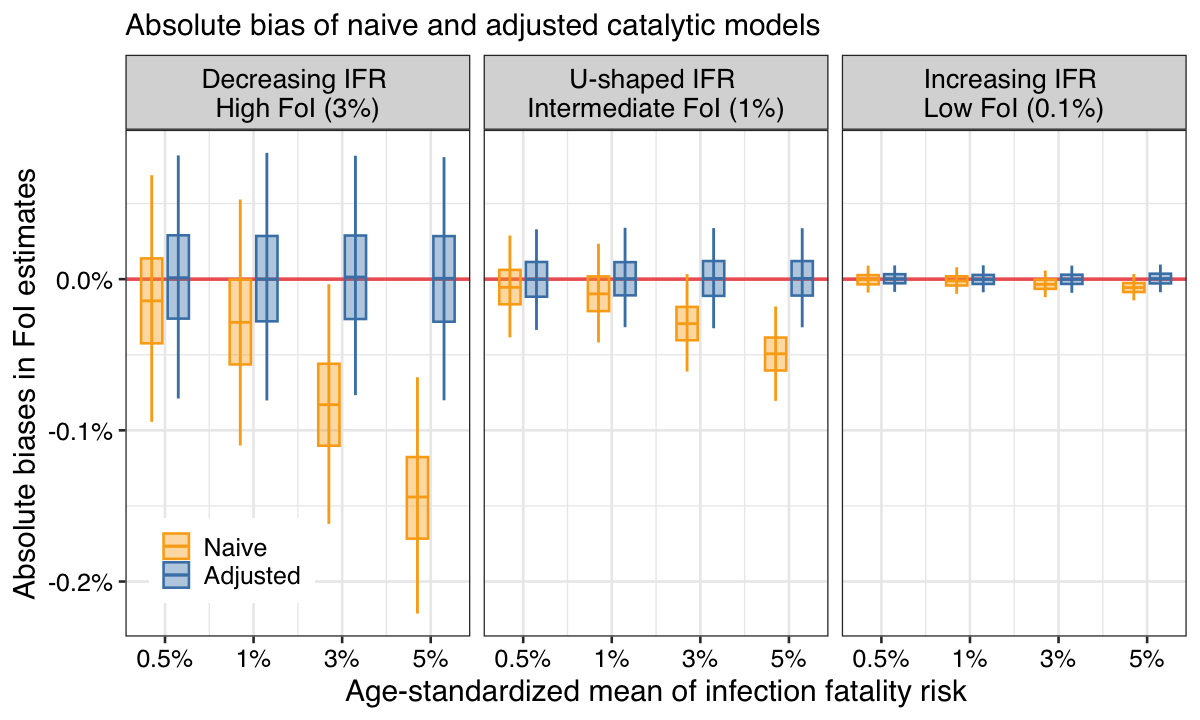

In [19]:
## plotting the absolute differences in the estimates
df_abs <- df_est_box %>% 
mutate(foi_abs = foi - correct, est_lower_abs = est_lower - correct, est_upper_abs = est_upper - correct,
       est_25_abs = est_25 - correct, est_75_abs = est_75 - correct)

y_min_abs <- 0
y_max_abs <- max(df_abs$est_upper_abs, na.rm = TRUE)
span_abs <- y_max_abs - y_min_abs
y_lim_abs <- c(y_min_abs, y_max_abs + .1 * span_abs)

options(repr.plot.width = 10, repr.plot.height = 6)

ggplot() +
geom_hline(yintercept = 0, color = "indianred2", linewidth = 1) +
geom_segment(data = df_abs, aes(x = x_center, xend = x_center, y = est_lower_abs, yend = est_upper_abs, color = group), linewidth = .8) +
geom_rect(data = df_abs, aes(xmin = x_center - .12, xmax = x_center + .12, 
                             ymin = est_25_abs, ymax = est_75_abs, fill = group, color = group), alpha = .4) +
geom_segment(data = df_abs, aes(x = x_center - .12, xend = x_center + .12, 
                                y = foi_abs, yend = foi_abs, color = group), linewidth = .8) +
facet_wrap(~ IFR_class_label) +
scale_color_manual(values = c("Naive" = "#FAAB18", "Adjusted" = "steelblue"), breaks = c("Naive", "Adjusted"),
                   guide = guide_legend(override.aes = list(fill = c("#FAAB18", "steelblue")))) +
scale_fill_manual(values = c("Naive" = "#FAAB18", "Adjusted" = "steelblue"), guide  = "none") +
scale_x_continuous(breaks = 1:length(target_IFR), labels = if_labels, 
                   name = "Age-standardized mean of infection fatality risk") +
scale_y_continuous(labels = scales::percent_format(accuracy = .1), 
                   name = "Absolute biases in FoI estimates") +
labs(title = "Absolute bias of naive and adjusted catalytic models") +
theme_bw(base_size = 16) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 15, family = "sans", color = "black"),
      legend.position = "inside", legend.position.inside = c(.1, .15),
      legend.text = element_text(size = 15, color = "black"), legend.title = element_blank(),
      plot.title = element_text(size = 18, family = "sans", color = "black"),
      strip.text = element_text(size = 16, family = "sans", color = "black"),
      legend.key = element_rect(fill = "transparent"))

ggsave("figures/comparison_single_box_diff.png", width = 10, height = 6, dpi = 300, bg = "white")

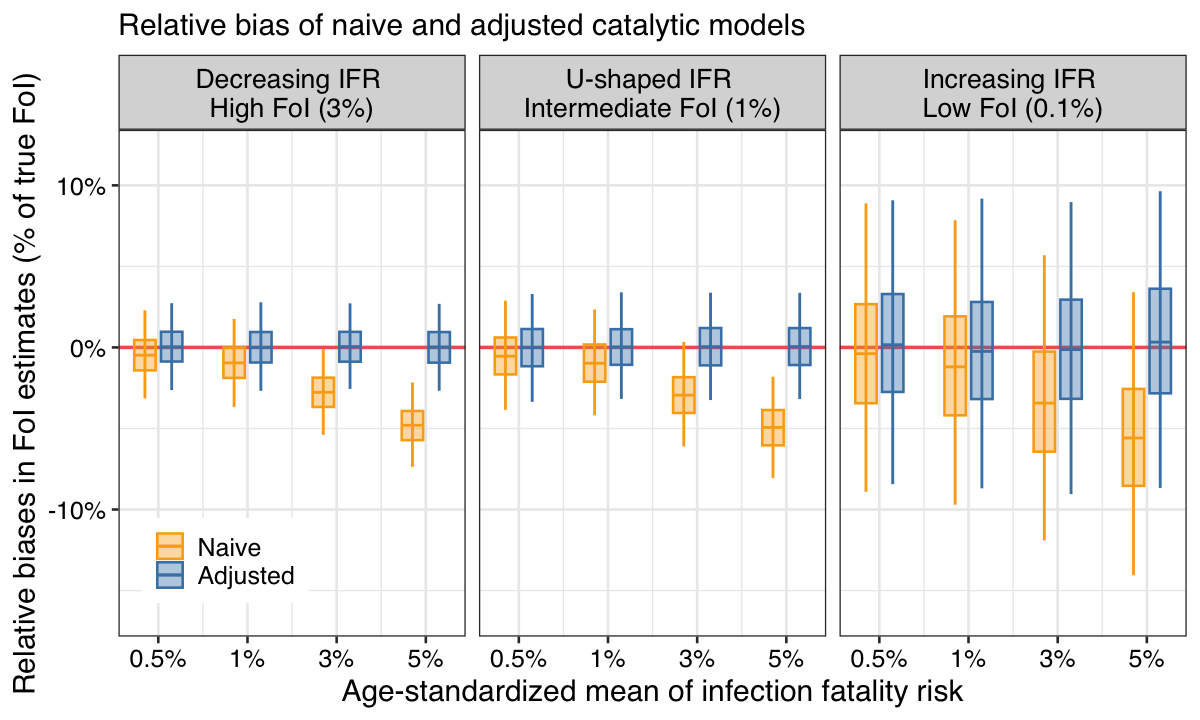

In [17]:
## plotting the relative differences in the estimates
df_rel <- df_est_box %>% 
mutate(foi_rel = (foi - correct) / correct,
       est_lower_rel = (est_lower - correct) / correct, est_upper_rel = (est_upper - correct) / correct,
       est_25_rel = (est_25 - correct) / correct, est_75_rel = (est_75 - correct) / correct)

y_min_rel <- min(df_rel$est_lower_rel, na.rm = TRUE)
y_max_rel <- max(df_rel$est_upper_rel, na.rm = TRUE)
span_rel <- y_max_rel - y_min_rel
y_lim_rel <- c(y_min_rel - .1 * span_rel, y_max_rel + .1 * span_rel)

options(repr.plot.width = 10, repr.plot.height = 6)

ggplot() +
geom_hline(yintercept = 0, color = "indianred2", linewidth = 1) +
geom_segment(data = df_rel, aes(x = x_center, xend = x_center, y = est_lower_rel, yend = est_upper_rel, color = group), linewidth = .8) +
geom_rect(data = df_rel, aes(xmin = x_center - .12, xmax = x_center + .12,
                             ymin = est_25_rel, ymax = est_75_rel, fill = group, color = group), alpha = .4) +
geom_segment(data = df_rel, aes(x = x_center - .12, xend = x_center + .12, y = foi_rel, yend = foi_rel, color = group), linewidth = .8) +
facet_wrap(~ IFR_class_label) +
scale_color_manual(values = c("Naive" = "#FAAB18", "Adjusted" = "steelblue"), breaks = c("Naive", "Adjusted"),
                   guide  = guide_legend(override.aes = list(fill = c("#FAAB18", "steelblue")))) +
scale_fill_manual(values = c("Naive" = "#FAAB18", "Adjusted" = "steelblue"), guide  = "none") +
scale_x_continuous(breaks = 1:length(target_IFR), labels = if_labels, 
                   name = "Age-standardized mean of infection fatality risk") +
scale_y_continuous(limits = y_lim_rel, labels = scales::percent_format(accuracy = 1), 
                   name = "Relative biases in FoI estimates (% of true FoI)") +
labs(title = "Relative bias of naive and adjusted catalytic models") +
theme_bw(base_size = 16) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 15, family = "sans", color = "black"),
      legend.position = "inside", legend.position.inside = c(.1, .15),
      legend.text = element_text(size = 15, color = "black"), legend.title = element_blank(),
      plot.title = element_text(size = 18, family = "sans", color = "black"),
      strip.text = element_text(size = 16, family = "sans", color = "black"),
      legend.key = element_rect(fill = "transparent"))

ggsave("figures/comparison_single_box_rel.png", width = 10, height = 6, dpi = 300, bg = "white")

In [13]:
system("jupyter nbconvert --to script catalyticmodel_comparison_constant.ipynb")